In [35]:
from pydmd import DMD
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# Load data
img = scipy.io.loadmat('..\data\imgV2.mat')
img = img["imgV2"]

In [57]:
# Make DMD Matrices
fs = 50
nSamples = 1000
nPixels = img.shape[0]*img.shape[1]
t = np.arange(0,nSamples) / fs # np.linspace(0,(nSamples-1) / fs,nSamples)
x = np.arange(1,nPixels+1)
xgrid, tgrid = np.meshgrid(x, t)
X = np.reshape(img[:,:,256:256+nSamples],(nPixels,nSamples)).T

In [66]:
# Fit Koopman
rank = 8
dmd = HankelDMD(svd_rank=rank)
dmd.fit(X)

C:\Users\dfpsi\AppData\Roaming\Python\Python39\site-packages\pydmd\dmdbase.py:326: UserWarning: Input data matrix X has condition number 1.185939808665824e+83. Consider preprocessing data, passing in augmented data matrix, or regularization methods.
  """


Eigenvalue (-0.3421488297931113+0j): distance from unit circle 0.8829341782712046
Eigenvalue (-0.019073685110652824+0j): distance from unit circle 0.9996361945362997
Eigenvalue (0.24593649206150223+0j): distance from unit circle 0.9395152418724827
Eigenvalue (0.5335102168688702+0j): distance from unit circle 0.715366848496531
Eigenvalue (0.9526654060342591+0.129870335618943j): distance from unit circle 0.07556232007180341
Eigenvalue (0.9526654060342591-0.129870335618943j): distance from unit circle 0.07556232007180341
Eigenvalue (0.9835524582959739+0j): distance from unit circle 0.03262456177994644
Eigenvalue (0.9551415461684332+0j): distance from unit circle 0.08770462678297486


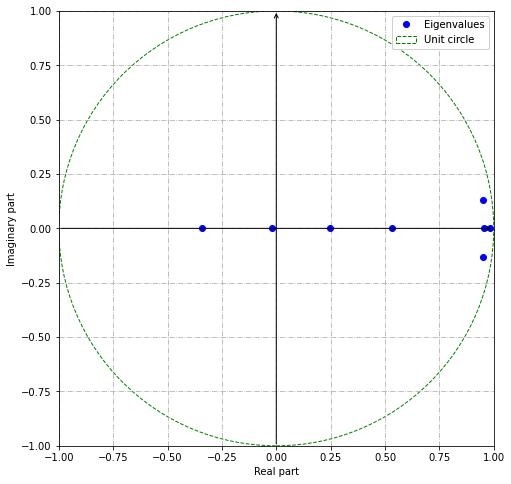

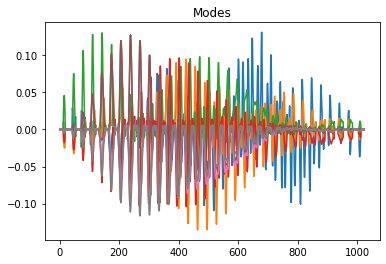

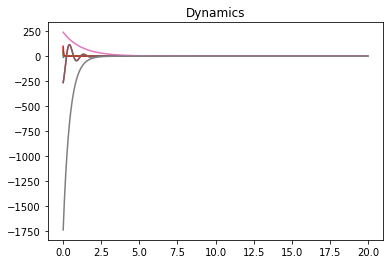

In [64]:
# DMD Plots
for eig in dmd.eigs:
    print('Eigenvalue {}: distance from unit circle {}'.format(eig, np.abs(eig.imag**2+eig.real**2 - 1)))

dmd.plot_eigs(show_axes=True, show_unit_circle=True)

for mode in dmd.modes.T:
    plt.plot(t, mode.real)
    plt.title('Modes')
plt.show()

for dynamic in dmd.dynamics:
    plt.plot(x, dynamic.real)
    plt.title('Dynamics')
plt.show()


<ipython-input-65-8fa455c2015a>:5: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  plt.pcolor(xgrid, tgrid, (mode.reshape(-1, 1).dot(dynamic.reshape(1, -1))).real.T)
<ipython-input-65-8fa455c2015a>:8: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  plt.pcolor(xgrid, tgrid, dmd.reconstructed_data.T.real)


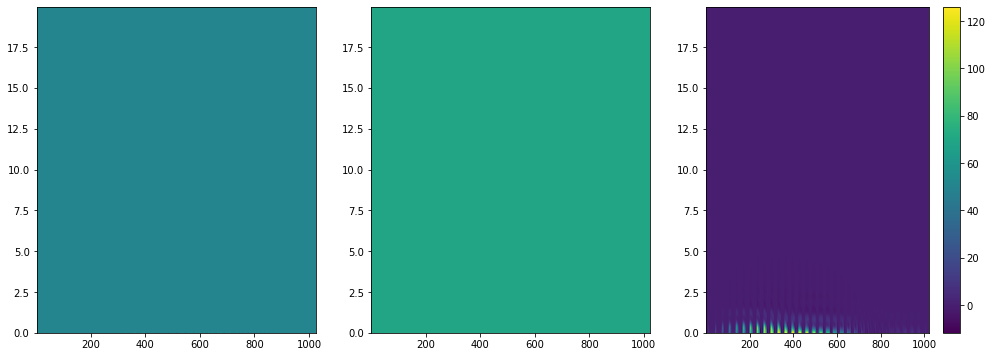

In [65]:


fig = plt.figure(figsize=(17,6))

for n, mode, dynamic in zip(range(131, 133), dmd.modes.T, dmd.dynamics):
    plt.subplot(n)
    plt.pcolor(xgrid, tgrid, (mode.reshape(-1, 1).dot(dynamic.reshape(1, -1))).real.T)
    
plt.subplot(133)
plt.pcolor(xgrid, tgrid, dmd.reconstructed_data.T.real)
plt.colorbar()

plt.show()



In [19]:


def f1(x,t): 
    return 1./np.cosh(x+3)*np.exp(2.3j*t)

def f2(x,t):
    return 2./np.cosh(x)*np.tanh(x)*np.exp(2.8j*t)

x = np.linspace(-5, 5, 128)
t = np.linspace(0, 4*np.pi, 256)

xgrid, tgrid = np.meshgrid(x, t)

X1 = f1(xgrid, tgrid)
X2 = f2(xgrid, tgrid)
X = X1 + X2

